# Fairness in Machine Learning with Folktables

## What is Folktables?

**Folktables** is a Python package that provides access to the **American Community Survey (ACS)** — a large annual survey conducted by the U.S. Census Bureau covering income, employment, housing, health coverage, and more.

It was created as a direct response to the widely-used **Adult / UCI Income dataset**, which has serious problems as a fairness benchmark:
- It's based on 1994 Census data — over 30 years out of date
- It uses a single arbitrary income threshold ($50K)
- It can't be used to study geographic or temporal variation
- It has documentation gaps and encoding issues

Folktables fixes all of these problems. You can choose the **year**, **state**, **survey type**, **prediction target**, and **sensitive attribute** — making it a much more flexible and realistic fairness benchmark.

### Key References
- [Retiring Adult: New Datasets for Fair Machine Learning](https://openreview.net/forum?id=bYi_2708mKK) — the paper introducing folktables
- [Folktables on GitHub](https://github.com/socialfoundations/folktables)
- [Folktables Datasheet](https://github.com/socialfoundations/folktables/blob/main/datasheet.md)

---
## 1. Setup

We'll use two key packages:
- **`folktables`** — for loading ACS data
- **`fairlearn`** — for fairness metrics and analysis

And of course, the usual data science stack:
- **`scikit-learn`** — for building ML models

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Prettier plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [1]:
try:
    import fairlearn
    from fairlearn.metrics import MetricFrame, selection_rate, false_negative_rate, false_positive_rate
    print(f"fairlearn version: {fairlearn.__version__}")
except ImportError:
    !pip install fairlearn -q
    import fairlearn
    from fairlearn.metrics import MetricFrame, selection_rate, false_negative_rate, false_positive_rate
    print(f"fairlearn version: {fairlearn.__version__}")

fairlearn version: 0.13.0


In [3]:
try:
    import folktables
    from folktables import ACSDataSource, ACSEmployment, ACSIncome, ACSPublicCoverage
    print(f"folktables version: {folktables.__version__}")
except ImportError:
    !pip install folktables -q
    import folktables
    from folktables import ACSDataSource, ACSEmployment, ACSIncome, ACSPublicCoverage
    print(f"folktables version: {folktables.__version__}")

folktables version: 0.0.12


---
## 2. Configuration — States and Year of Interest

Rather than hard-coding state names throughout the notebook, we declare them here as variables. This makes it easy to swap states for your own analysis.

We're using **Alabama** and **Oregon** as our two states of interest:
- **Alabama** — Southern state, lower median income, historically significant context for racial equity
- **Oregon** — Pacific Northwest state, higher median income, different racial composition

> **Note:** We avoid California here because its large population means large files — which can be slow or problematic on shared JupyterHub environments.

In [4]:
# ---- Change these to explore different states ----
STATE_1 = "AL"   # Alabama
STATE_2 = "OR"   # Oregon
SURVEY_YEAR = '2018'
# --------------------------------------------------

STATE_NAMES = {"AL": "Alabama", "OR": "Oregon"}  # for readable labels
print(f"Primary state:   {STATE_NAMES.get(STATE_1, STATE_1)} ({STATE_1})")
print(f"Secondary state: {STATE_NAMES.get(STATE_2, STATE_2)} ({STATE_2})")
print(f"Survey year:     {SURVEY_YEAR}")

Primary state:   Alabama (AL)
Secondary state: Oregon (OR)
Survey year:     2018


---
## 3. What Years Are Available in Folktables?

Folktables pulls from the **ACS Public Use Microdata Sample (PUMS)**, which is available in two forms:
- **1-Year estimates** — larger sample, available for most states from **2014 to 2022**
- **5-Year estimates** — pooled over 5 years, available for smaller geographies

> **Important:** 2020 data is **not available** from folktables. The 2020 ACS 1-Year survey was not released publicly by the Census Bureau due to data quality issues caused by COVID-19 response disruptions.

The cell below confirms which years folktables can successfully load data for Alabama.


### Survey Types

| Type | Description |
|------|-------------|
| `'person'` | Individual-level data (income, employment, health coverage) |
| `'household'` | Household-level data |

### Pre-built Prediction Tasks

| Task | Prediction question |
|------|---------------------|
| `ACSIncome` | Does a person earn more than $50K/year? |
| `ACSEmployment` | Is a person employed? |
| `ACSMobility` | Did a person move in the past year? |
| `ACSPublicCoverage` | Does a person have public health insurance? |
| `ACSTravelTime` | Does a person commute more than 20 minutes? |

---
## 4. Load Data — Alabama 2018, Employment Task

We'll start with the **ACSEmployment** task: predicting whether a person is employed, using Alabama 2018 data.

### ACSEmployment features
| Feature | Description |
|---------|-------------|
| `AGEP`  | Age |
| `SCHL`  | Educational attainment |
| `MAR`   | Marital status |
| `RELP`  | Relationship to household head |
| `DIS`   | Disability status |
| `ESP`   | Employment status of parents |
| `CIT`   | Citizenship |
| `MIG`   | Mobility (moved in past year) |
| `MIL`   | Military service |
| `ANC`   | Ancestry |
| `NATIVITY` | Native or foreign born |
| `DEAR`  | Hearing difficulty |
| `DEYE`  | Vision difficulty |
| `DREM`  | Cognitive difficulty |
| `SEX`   | Sex |
| `RAC1P` | Race (used as sensitive attribute) |

**Target:** `ESR` — Employment Status Recode (is the person employed?)

**Sensitive attribute:** `RAC1P` — Race, where `1 = White alone`, `2 = Black or African American alone`

In [6]:
# Load Alabama 2018 data
data_source = ACSDataSource(survey_year=SURVEY_YEAR, horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=[STATE_1], download=True)

print(f"Raw ACS data shape: {acs_data.shape}")
print(f"Columns: {list(acs_data.columns[:10])} ... ({len(acs_data.columns)} total)")

Raw ACS data shape: (47777, 286)
Columns: ['RT', 'SERIALNO', 'DIVISION', 'SPORDER', 'PUMA', 'REGION', 'ST', 'ADJINC', 'PWGTP', 'AGEP'] ... (286 total)


In [7]:
# Extract features, label, and group for the Employment task
features, label, group = ACSEmployment.df_to_numpy(acs_data)

print(f"Features shape:  {features.shape}")
print(f"Label shape:     {label.shape}  — 1 = Employed, 0 = Not employed")
print(f"Group shape:     {group.shape}  — race codes from RAC1P")
print()
print("Group value counts (RAC1P race codes):")
unique, counts = np.unique(group, return_counts=True)
race_labels = {1: 'White alone', 2: 'Black/African American alone',
               3: 'American Indian alone', 4: 'Alaska Native alone',
               5: 'American Indian & Alaska Native tribes', 6: 'Asian alone',
               7: 'Native Hawaiian / Pacific Islander', 8: 'Some other race', 9: 'Two or more races'}
for code, count in zip(unique, counts):
    label_str = race_labels.get(int(code), f'Code {int(code)}')
    print(f"  RAC1P={int(code)}: {count:>6,}  ({label_str})")

Features shape:  (47777, 16)
Label shape:     (47777,)  — 1 = Employed, 0 = Not employed
Group shape:     (47777,)  — race codes from RAC1P

Group value counts (RAC1P race codes):
  RAC1P=1: 35,551  (White alone)
  RAC1P=2: 10,115  (Black/African American alone)
  RAC1P=3:    182  (American Indian alone)
  RAC1P=4:      1  (Alaska Native alone)
  RAC1P=5:     33  (American Indian & Alaska Native tribes)
  RAC1P=6:    556  (Asian alone)
  RAC1P=7:     13  (Native Hawaiian / Pacific Islander)
  RAC1P=8:    491  (Some other race)
  RAC1P=9:    835  (Two or more races)


---
## 5. Exploratory Data Analysis (EDA)

Before building a model, it's important to understand the structure and distribution of the data.
We'll look at:
- Class balance (employed vs. not employed)
- Racial composition of the sample
- Employment rates by race
- Distribution of a few key features

In [8]:
# Build a DataFrame for easier EDA
feature_names = ['AGEP', 'SCHL', 'MAR', 'RELP', 'DIS', 'ESP', 'CIT', 'MIG',
                 'MIL', 'ANC', 'NATIVITY', 'DEAR', 'DEYE', 'DREM', 'SEX', 'RAC1P']
df_eda = pd.DataFrame(features, columns=feature_names)
df_eda['employed'] = label.astype(int)
df_eda['race_code'] = group.astype(int)

# Keep White (1) and Black (2) for focused analysis
df_wb = df_eda[df_eda['race_code'].isin([1, 2])].copy()
df_wb['race_label'] = df_wb['race_code'].map({1: 'White', 2: 'Black'})

print(f"Full sample:             {len(df_eda):,} individuals")
print(f"White + Black subsample: {len(df_wb):,} individuals")
print()
print(df_eda[['AGEP', 'SCHL', 'employed']].describe().round(2))

Full sample:             47,777 individuals
White + Black subsample: 45,666 individuals

           AGEP      SCHL  employed
count  47777.00  47777.00  47777.00
mean      42.78     15.52      0.41
std       23.80      5.91      0.49
min        0.00      0.00      0.00
25%       22.00     14.00      0.00
50%       45.00     16.00      0.00
75%       62.00     20.00      1.00
max       93.00     24.00      1.00


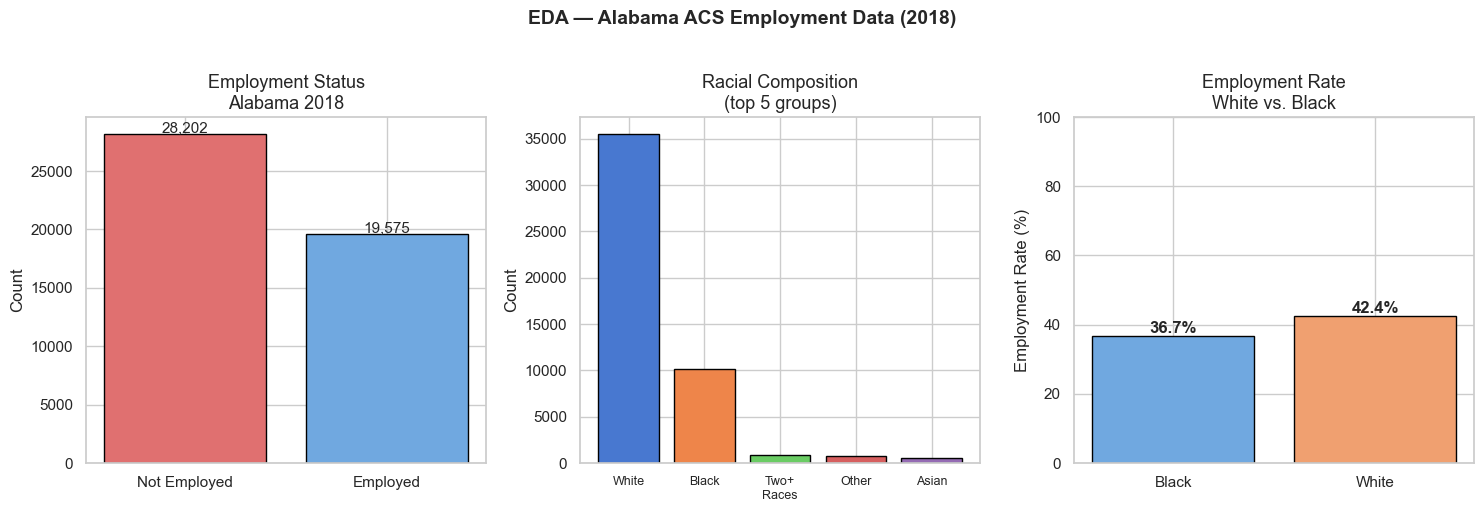

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: Overall class balance ---
emp_counts = df_eda['employed'].value_counts()
axes[0].bar(['Not Employed', 'Employed'], emp_counts[[0, 1]], color=['#e07070', '#70a8e0'], edgecolor='black')
axes[0].set_title(f'Employment Status\n{STATE_NAMES[STATE_1]} {SURVEY_YEAR}', fontsize=13)
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, emp_counts[[0, 1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=11)

# --- Panel 2: Racial composition (top 3) ---
race_map = {1: 'White', 2: 'Black', 6: 'Asian', 9: 'Two+\nRaces', 8: 'Other'}
df_eda['race_label_all'] = df_eda['race_code'].map(race_map).fillna('Other')
race_order = df_eda['race_label_all'].value_counts().index
race_vals  = df_eda['race_label_all'].value_counts()
axes[1].bar(race_order[:5], race_vals.iloc[:5], color=sns.color_palette('muted', 5), edgecolor='black')
axes[1].set_title('Racial Composition\n(top 5 groups)', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', labelsize=9)

# --- Panel 3: Employment rate by race (White vs Black) ---
emp_by_race = df_wb.groupby('race_label')['employed'].mean() * 100
bars = axes[2].bar(emp_by_race.index, emp_by_race.values,
                   color=['#70a8e0', '#f0a070'], edgecolor='black')
axes[2].set_title('Employment Rate\nWhite vs. Black', fontsize=13)
axes[2].set_ylabel('Employment Rate (%)')
axes[2].set_ylim(0, 100)
for bar, val in zip(bars, emp_by_race.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle(f'EDA — {STATE_NAMES[STATE_1]} ACS Employment Data ({SURVEY_YEAR})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

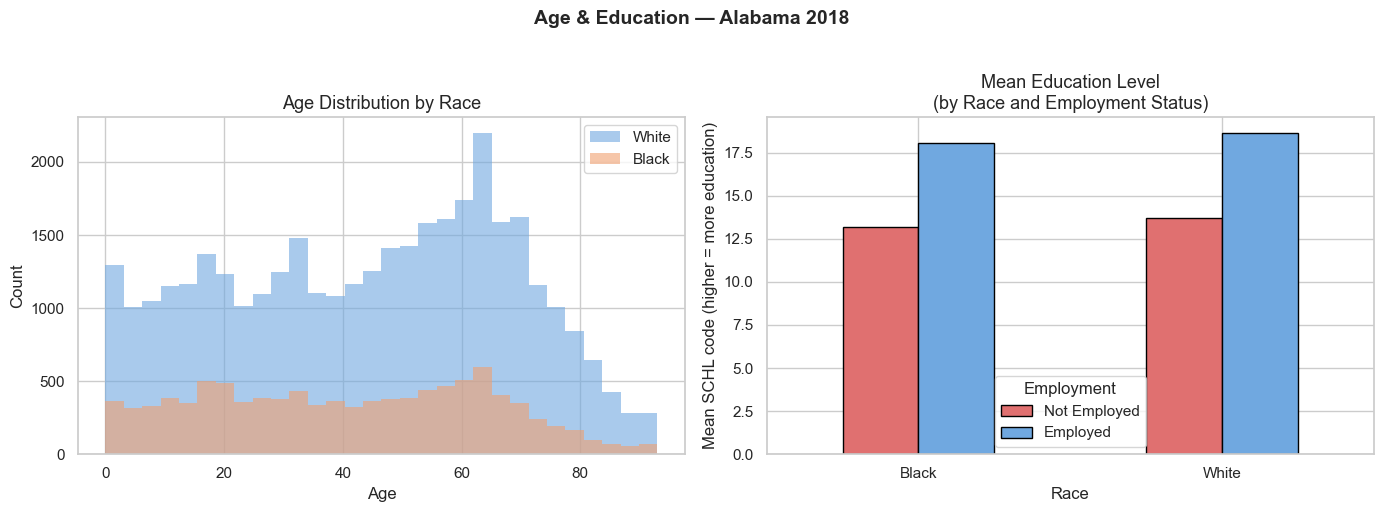

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Age distribution by race ---
for race, color in zip(['White', 'Black'], ['#70a8e0', '#f0a070']):
    subset = df_wb[df_wb['race_label'] == race]['AGEP']
    axes[0].hist(subset, bins=30, alpha=0.6, label=race, color=color, edgecolor='none')
axes[0].set_title('Age Distribution by Race', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Education level by race and employment ---
edu_emp = df_wb.groupby(['race_label', 'employed'])['SCHL'].mean().unstack()
edu_emp.columns = ['Not Employed', 'Employed']
edu_emp.plot(kind='bar', ax=axes[1], color=['#e07070', '#70a8e0'], edgecolor='black', rot=0)
axes[1].set_title('Mean Education Level\n(by Race and Employment Status)', fontsize=13)
axes[1].set_xlabel('Race')
axes[1].set_ylabel('Mean SCHL code (higher = more education)')
axes[1].legend(title='Employment')

plt.suptitle(f'Age & Education — {STATE_NAMES[STATE_1]} {SURVEY_YEAR}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Exploring Two States — Alabama vs. Oregon

One of folktables' key advantages over the Adult dataset is the ability to compare across **states** and **years**.
Here we load both Alabama and Oregon and compare their racial composition and employment rates side by side.

In [11]:
# Load Oregon data (reuse the same data_source since the year is the same)
acs_data_s2 = data_source.get_data(states=[STATE_2], download=True)
features_s2, label_s2, group_s2 = ACSEmployment.df_to_numpy(acs_data_s2)

print(f"Alabama sample size: {len(label):,} individuals")
print(f"Oregon  sample size: {len(label_s2):,} individuals")

Alabama sample size: 47,777 individuals
Oregon  sample size: 42,117 individuals


In [12]:
def state_summary(lbl, grp, state_name):
    """Return a summary dict for a state's employment data."""
    white_mask = grp == 1
    black_mask = grp == 2
    return {
        'State': state_name,
        'Total N': len(lbl),
        'Overall Employment Rate': f"{lbl.mean()*100:.1f}%",
        'White N': white_mask.sum(),
        'Black N': black_mask.sum(),
        'White Employment Rate': f"{lbl[white_mask].mean()*100:.1f}%",
        'Black Employment Rate': f"{lbl[black_mask].mean()*100:.1f}%",
        'Gap (White - Black)': f"{(lbl[white_mask].mean() - lbl[black_mask].mean())*100:.1f} pp",
    }

summary_al = state_summary(label,    group,    STATE_NAMES[STATE_1])
summary_or = state_summary(label_s2, group_s2, STATE_NAMES[STATE_2])

summary_df = pd.DataFrame([summary_al, summary_or]).set_index('State')
print(summary_df.T.to_string())

State                   Alabama  Oregon
Total N                   47777   42117
Overall Employment Rate   41.0%   45.7%
White N                   35551   36322
Black N                   10115     628
White Employment Rate     42.4%   45.9%
Black Employment Rate     36.7%   41.2%
Gap (White - Black)      5.7 pp  4.7 pp


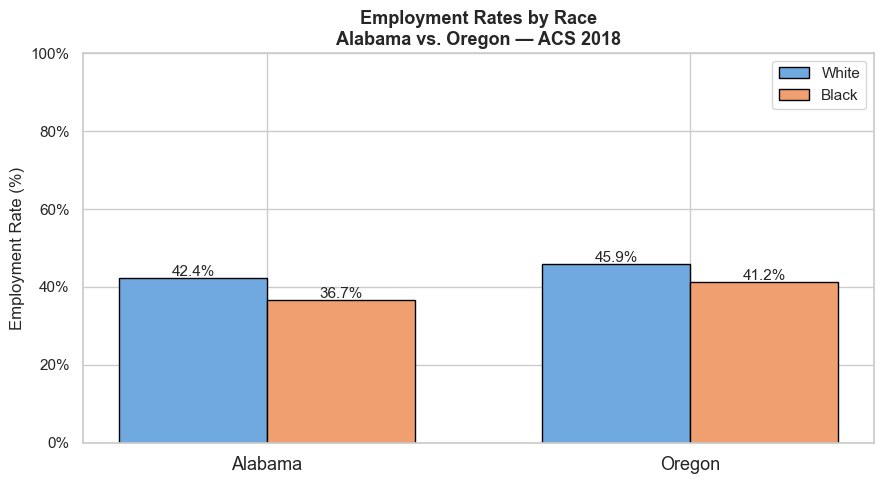

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

states   = [STATE_NAMES[STATE_1], STATE_NAMES[STATE_2]]
white_rates = [label[group == 1].mean() * 100,
               label_s2[group_s2 == 1].mean() * 100]
black_rates = [label[group == 2].mean() * 100,
               label_s2[group_s2 == 2].mean() * 100]

x = np.arange(len(states))
width = 0.35

bars1 = ax.bar(x - width/2, white_rates, width, label='White', color='#70a8e0', edgecolor='black')
bars2 = ax.bar(x + width/2, black_rates, width, label='Black', color='#f0a070', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(states, fontsize=13)
ax.set_ylim(0, 100)
ax.set_ylabel('Employment Rate (%)', fontsize=12)
ax.set_title(f'Employment Rates by Race\n{STATE_NAMES[STATE_1]} vs. {STATE_NAMES[STATE_2]} — ACS {SURVEY_YEAR}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

---
## 7. Train a Classifier — Alabama 2018

We'll train a **Logistic Regression** model to predict employment status from the ACS features.

The pipeline:
1. **StandardScaler** — normalize features to zero mean and unit variance
2. **LogisticRegression** — a simple linear classifier (a good baseline)

We split into 80% training / 20% test, stratifying by group so the test set has proportional representation.

In [14]:
# Train/test split — keeping group labels aligned with features and labels
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    features, label, group, test_size=0.2, random_state=42
)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
model.fit(X_train, y_train)

yhat = model.predict(X_test)

print(f"Overall test accuracy: {(yhat == y_test).mean():.4f}")
print()
print(classification_report(y_test, yhat, target_names=['Not Employed', 'Employed']))

Overall test accuracy: 0.7810

              precision    recall  f1-score   support

Not Employed       0.83      0.80      0.81      5656
    Employed       0.72      0.76      0.74      3900

    accuracy                           0.78      9556
   macro avg       0.77      0.78      0.77      9556
weighted avg       0.78      0.78      0.78      9556



---
## 8. Equality of Opportunity

### What does it mean?

A model satisfies **Equality of Opportunity** if it has the **same True Positive Rate (TPR)** across demographic groups.

**True Positive Rate (TPR)** — also called *recall* or *sensitivity* — answers the question:
> *"Of all the people who ARE employed, what fraction does the model correctly identify as employed?"*

$$\text{TPR} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} = \frac{TP}{TP + FN}$$

### Why does it matter here?

If a model has a **lower TPR for Black individuals** than for White individuals, it means:
- The model is more likely to *miss* actually-employed Black people — predicting them as "not employed"
- This is a **false negative** — a person who should be recognized as employed is not

In real-world applications — like a hiring tool, a loan classifier, or a benefit eligibility system — this gap translates directly to unequal outcomes for people who are equally qualified.

### The Equality of Opportunity violation

The **violation** is measured as:
$$\text{EO Violation} = \text{TPR}_{\text{White}} - \text{TPR}_{\text{Black}}$$

A violation of `0.0` means perfect equality of opportunity. A positive value means White individuals get higher TPR — a form of algorithmic discrimination against Black individuals.

In [15]:
# Compute True Positive Rate for White (RAC1P=1) and Black (RAC1P=2)
white_mask = (y_test == 1) & (group_test == 1)
black_mask = (y_test == 1) & (group_test == 2)

white_tpr = np.mean(yhat[white_mask])
black_tpr = np.mean(yhat[black_mask])
eo_violation = white_tpr - black_tpr

print(f"White True Positive Rate:   {white_tpr:.4f}  ({white_tpr*100:.1f}%)")
print(f"Black True Positive Rate:   {black_tpr:.4f}  ({black_tpr*100:.1f}%)")
print()
print(f"Equality of Opportunity Violation: {eo_violation:.4f}  ({eo_violation*100:.1f} percentage points)")
print()
if eo_violation > 0.05:
    print("⚠ The model has a meaningful EO violation — it is significantly better at")
    print("  correctly identifying employed White individuals than employed Black individuals.")
elif eo_violation > 0.01:
    print("~ Small EO violation present — worth monitoring.")
else:
    print("✓ EO violation is negligible.")

White True Positive Rate:   0.7777  (77.8%)
Black True Positive Rate:   0.6781  (67.8%)

Equality of Opportunity Violation: 0.0996  (10.0 percentage points)

⚠ The model has a meaningful EO violation — it is significantly better at
  correctly identifying employed White individuals than employed Black individuals.


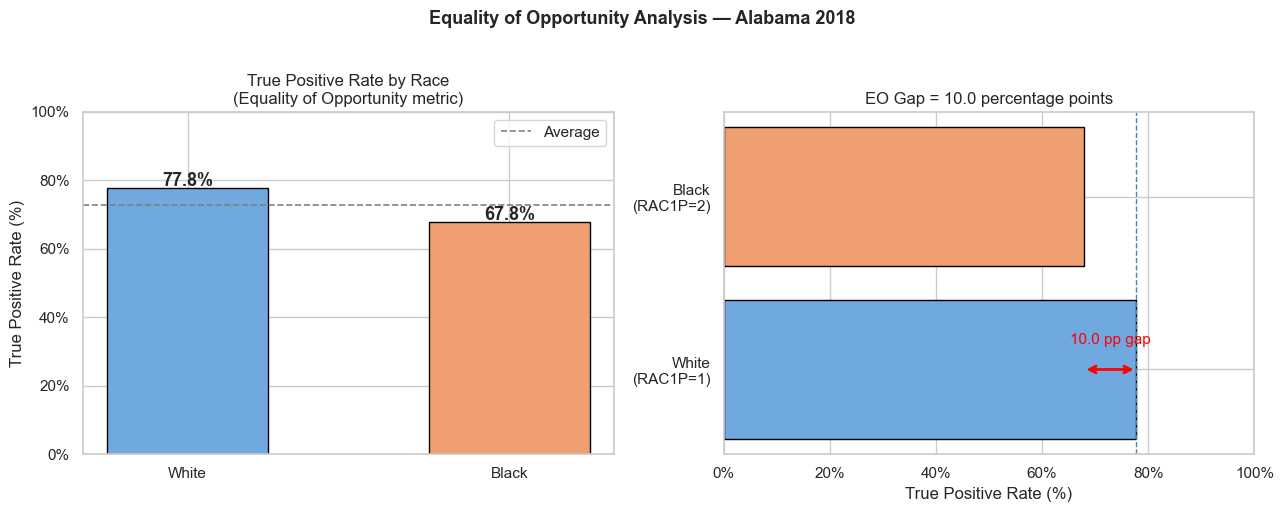

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: TPR comparison bar chart ---
tprs   = [white_tpr * 100, black_tpr * 100]
labels = ['White', 'Black']
colors = ['#70a8e0', '#f0a070']
bars = axes[0].bar(labels, tprs, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, tprs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].axhline(np.mean(tprs), color='gray', linestyle='--', linewidth=1.2, label='Average')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('True Positive Rate (%)', fontsize=12)
axes[0].set_title('True Positive Rate by Race\n(Equality of Opportunity metric)', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend()

# --- Right: Annotated gap visualization ---
axes[1].barh(['White\n(RAC1P=1)', 'Black\n(RAC1P=2)'],
             [white_tpr * 100, black_tpr * 100],
             color=colors, edgecolor='black')
axes[1].axvline(white_tpr * 100, color='steelblue', linestyle='--', linewidth=1)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('True Positive Rate (%)', fontsize=12)
axes[1].set_title(f'EO Gap = {eo_violation*100:.1f} percentage points', fontsize=12)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

# Draw gap annotation
axes[1].annotate('', xy=(black_tpr*100, 0), xytext=(white_tpr*100, 0),
                 arrowprops=dict(arrowstyle='<->', color='red', lw=2))
axes[1].text((white_tpr + black_tpr)/2 * 100, 0.15,
             f'{eo_violation*100:.1f} pp gap', ha='center', color='red', fontsize=11)

plt.suptitle(f'Equality of Opportunity Analysis — {STATE_NAMES[STATE_1]} {SURVEY_YEAR}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Using Fairlearn's MetricFrame

Rather than computing each metric by hand, **`MetricFrame`** takes a dictionary of metrics and a sensitive attribute column and computes everything by group at once. It also gives you the **group difference** and **group ratio** for each metric — useful for quickly scanning where disparities are largest.

In [ ]:
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, true_positive_rate, false_negative_rate, false_positive_rate, selection_rate

# Only compare White (1) and Black (2) groups
wb_mask = (group_test == 1) | (group_test == 2)
race_labels_test = np.where(group_test[wb_mask] == 1, 'White', 'Black')

mf = MetricFrame(
    metrics={
        'accuracy':          accuracy_score,
        'true_positive_rate': true_positive_rate,
        'false_negative_rate': false_negative_rate,
        'false_positive_rate': false_positive_rate,
        'selection_rate':     selection_rate,
    },
    y_true=y_test[wb_mask],
    y_pred=yhat[wb_mask],
    sensitive_features=race_labels_test,
)

print("=== Metrics by group ===")
print(mf.by_group.round(3).to_string())
print()
print("=== Difference (max - min across groups) ===")
print(mf.difference().round(3).to_string())
print()
print("=== Ratio (min / max across groups) ===")
print(mf.ratio().round(3).to_string())

### Reading the MetricFrame Output

#### Metrics by group

| Metric | White | Black | What it means |
|--------|-------|-------|---------------|
| **Accuracy** | 0.786 | 0.763 | Overall, the model is slightly more accurate for White individuals — but the gap is small (2.3 pp) |
| **True Positive Rate** | 0.778 | 0.678 | Of people who *are* employed, the model correctly identifies 77.8% of White individuals but only 67.8% of Black individuals — a **10 pp gap** |
| **False Negative Rate** | 0.222 | 0.322 | The flip side of TPR: the model *misses* 32% of employed Black individuals vs. 22% of employed White individuals |
| **False Positive Rate** | 0.208 | 0.186 | Of people who are *not* employed, the model incorrectly predicts employment at similar rates for both groups — this disparity is small |
| **Selection Rate** | 0.447 | 0.370 | The model predicts employment for 44.7% of White individuals but only 37.0% of Black individuals — even though their actual employment rates are closer together |

#### Difference and Ratio

The **difference** (max − min) and **ratio** (min / max) give you two ways to measure the same disparity:

- A difference of `0.0` or ratio of `1.0` = perfect parity
- The **true positive rate** has the largest difference (0.100) and one of the lowest ratios (0.872) — confirming this is where the model is most unfair
- The **false negative rate** ratio of 0.691 means Black individuals are falsely classified as "not employed" at nearly **1.5× the rate** of White individuals — the starkest disparity in the table
- **Accuracy** looks nearly equal (ratio 0.971), which illustrates a classic trap: a model can appear fair by overall accuracy while hiding significant disparities in *who* it gets wrong

---
## 9. Confusion Matrices by Group

The confusion matrix breaks down model predictions into four categories:

|                      | Predicted: Not Employed | Predicted: Employed |
|----------------------|------------------------|---------------------|
| **Actual: Not Employed** | True Negative (TN) | False Positive (FP) |
| **Actual: Employed**     | False Negative (FN) | True Positive (TP) |

Comparing confusion matrices across racial groups reveals *where* the model makes different kinds of errors — not just the overall rate.

In [17]:
cm_white = confusion_matrix(y_test[group_test == 1], yhat[group_test == 1])
cm_black = confusion_matrix(y_test[group_test == 2], yhat[group_test == 2])

print("Confusion Matrix — White Group:")
print(cm_white)
print()
print("Confusion Matrix — Black Group:")
print(cm_black)

Confusion Matrix — White Group:
[[3278  861]
 [ 663 2320]]

Confusion Matrix — Black Group:
[[1027  234]
 [ 243  512]]


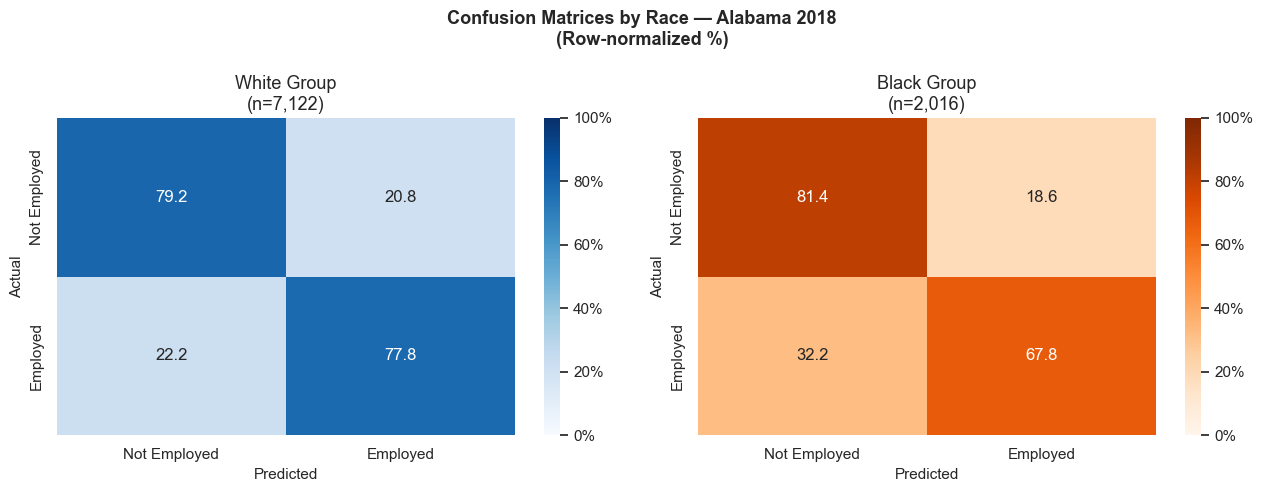

Interpretation:
  White FN rate (missed employed): 22.2%
  Black FN rate (missed employed): 32.2%

The Black group has a higher False Negative rate — the model misses more
actually-employed Black individuals, which is exactly the EO violation we measured above.


In [18]:
def plot_confusion_pct(ax, cm, title, cmap='Blues'):
    """Plot a confusion matrix as row-normalized percentages."""
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                xticklabels=['Not Employed', 'Employed'],
                yticklabels=['Not Employed', 'Employed'],
                vmin=0, vmax=100, cbar_kws={'format': '%.0f%%'})
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_pct(axes[0], cm_white, f'White Group\n(n={cm_white.sum():,})', cmap='Blues')
plot_confusion_pct(axes[1], cm_black, f'Black Group\n(n={cm_black.sum():,})', cmap='Oranges')

plt.suptitle(f'Confusion Matrices by Race — {STATE_NAMES[STATE_1]} {SURVEY_YEAR}\n(Row-normalized %)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretation:")
print(f"  White FN rate (missed employed): {cm_white[1,0]/cm_white[1,:].sum()*100:.1f}%")
print(f"  Black FN rate (missed employed): {cm_black[1,0]/cm_black[1,:].sum()*100:.1f}%")
print()
print("The Black group has a higher False Negative rate — the model misses more")
print("actually-employed Black individuals, which is exactly the EO violation we measured above.")

---
## 10. Custom Problem — Income with Gender as Sensitive Attribute

Folktables lets you define your own prediction task with custom:
- **Feature set** — which ACS columns to include
- **Target** — which column to predict
- **Target transform** — e.g., income > $25,000 (instead of the default $50K)
- **Sensitive attribute** — which column defines the group (here: `SEX`)

This is one of the key advantages of folktables over the Adult dataset — you're not locked into one fixed definition of the problem.

In [19]:
ACSIncomeNew = folktables.BasicProblem(
    features=[
        'COW',   # Class of worker
        'SCHL',  # Educational attainment
        'MAR',   # Marital status
        'OCCP',  # Occupation
        'POBP',  # Place of birth
        'RELP',  # Relationship
        'WKHP',  # Hours worked per week
        'SEX',   # Sex
        'RAC1P', # Race
    ],
    target='PINCP',                             # Personal income
    target_transform=lambda x: x > 25000,       # Threshold: $25K (not the default $50K)
    group='SEX',                                 # Sensitive attribute = Sex
    preprocess=folktables.adult_filter,          # Apply Adult-style age/income filter
    postprocess=lambda x: np.nan_to_num(x, -1), # Replace NaN with -1
)

print("Custom problem defined:")
print("  Target:    Personal income > $25,000")
print("  Group:     SEX (1 = Male, 2 = Female)")
print("  Filter:    adult_filter (working-age adults with non-zero income)")

Custom problem defined:
  Target:    Personal income > $25,000
  Group:     SEX (1 = Male, 2 = Female)
  Filter:    adult_filter (working-age adults with non-zero income)


In [20]:
# Apply custom problem to Alabama 2018 data
features_inc, labels_inc, groups_inc = ACSIncomeNew.df_to_numpy(acs_data)

X_tr, X_te, y_tr, y_te, g_tr, g_te = train_test_split(
    features_inc, labels_inc, groups_inc, test_size=0.2, random_state=42
)

model_inc = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
model_inc.fit(X_tr, y_tr)

yhat_inc = model_inc.predict(X_te)

# Accuracy by sex
gender_labels = {1: 'Male', 2: 'Female'}
print(f"Overall accuracy: {(yhat_inc == y_te).mean():.4f}")
print()
print("Accuracy by gender:")
for code, name in gender_labels.items():
    mask = g_te == code
    acc  = (yhat_inc[mask] == y_te[mask]).mean()
    tpr  = yhat_inc[(y_te == 1) & mask].mean() if (y_te == 1)[mask].sum() > 0 else float('nan')
    print(f"  {name:8s}: accuracy = {acc:.4f},  TPR = {tpr:.4f}")

male_tpr   = yhat_inc[(y_te == 1) & (g_te == 1)].mean()
female_tpr = yhat_inc[(y_te == 1) & (g_te == 2)].mean()
print(f"\nEO Violation (Male TPR - Female TPR): {male_tpr - female_tpr:.4f}")

Overall accuracy: 0.7784

Accuracy by gender:
  Male    : accuracy = 0.8172,  TPR = 0.9161
  Female  : accuracy = 0.7360,  TPR = 0.7934

EO Violation (Male TPR - Female TPR): 0.1226


---
## 11. Temporal Stability — Does the Model Hold Up Over Time?

Another strength of folktables: you can test whether a model trained on one year **generalizes** to later years.

Here we train on 2014 data and evaluate on each subsequent year through 2018.
A model that degrades sharply over time may be picking up on patterns that don't hold — a signal that it may not be trustworthy in deployment.

In [21]:
from folktables import ACSPublicCoverage

# Download 2014 Alabama data for training
ds_2014 = ACSDataSource(survey_year=2014, horizon='1-Year', survey='person')
acs_2014 = ds_2014.get_data(states=[STATE_1], download=True)
f14, l14, _ = ACSPublicCoverage.df_to_numpy(acs_2014)

model_2014 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
model_2014.fit(f14, l14)
print(f"Trained on {STATE_NAMES[STATE_1]} 2014 (n={len(l14):,})")

# Evaluate on 2015–2018
results = []
for year in [2015, 2016, 2017, 2018]:
    ds = ACSDataSource(survey_year=year, horizon='1-Year', survey='person')
    acs = ds.get_data(states=[STATE_1], download=True)
    f, l, _ = ACSPublicCoverage.df_to_numpy(acs)
    acc = model_2014.score(f, l)
    results.append((year, acc))
    print(f"  {year}: accuracy = {acc:.4f}")

Trained on Alabama 2014 (n=20,128)
  2015: accuracy = 0.8007
  2016: accuracy = 0.8042
  2017: accuracy = 0.7960
  2018: accuracy = 0.8021


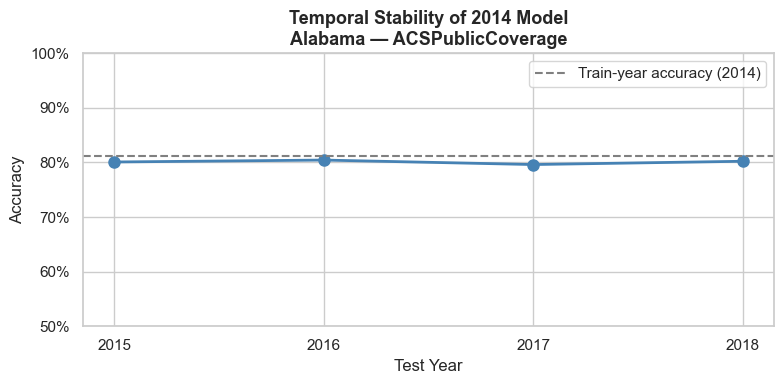

In [22]:
years, accs = zip(*results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(years, accs, marker='o', linewidth=2, color='steelblue', markersize=8)
ax.axhline(model_2014.score(f14, l14), color='gray', linestyle='--',
           label='Train-year accuracy (2014)')
ax.set_xticks(years)
ax.set_ylim(0.5, 1.0)
ax.set_xlabel('Test Year', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Temporal Stability of 2014 Model\n{STATE_NAMES[STATE_1]} — ACSPublicCoverage',
             fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

---
## Summary

In this notebook we:

1. **Introduced folktables** as a modern replacement for the Adult/UCI dataset, based on U.S. Census ACS data
2. **Configured state variables** — Alabama and Oregon — for reproducible, easy-to-modify analysis
3. **Surveyed available years** (2014–2022, excluding 2020) and prediction tasks
4. **Performed EDA** on Alabama 2018 employment data — class balance, racial composition, age and education distributions
5. **Compared two states** side-by-side on employment rates by race
6. **Trained a logistic regression model** and measured **Equality of Opportunity** — the gap in True Positive Rate between White and Black individuals
7. **Visualized confusion matrices** by group to understand where disparate errors occur
8. **Defined a custom prediction task** with a different income threshold and gender as the sensitive attribute
9. **Tested temporal stability** — checking whether a model trained in 2014 holds up through 2018

### Key Takeaway

> A model that looks accurate overall can still exhibit **systematic disparities** in who it correctly identifies. The **Equality of Opportunity** framework gives us a precise, measurable way to detect and quantify these disparities — and folktables gives us the data to study them across states, years, and demographic groups.